In [1]:
from pathlib import Path

from lunarsky import Time
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import lusee_faraday as ld

%matplotlib widget

In [2]:
# Define the publication style
pub_style = {
    # FONT CONFIGURATION
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 8,              # Base font size (usually 7-9pt for captions/axis)
    'axes.labelsize': 9,         # Axis labels slightly larger
    'axes.titlesize': 10,        # Title slightly larger
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,

    # LINE AND MARKER CONFIGURATION
    'lines.linewidth': 1.5,      # Thicker lines for visibility
    'lines.markersize': 5,
    'axes.linewidth': 1,         # Thicker axes frame (spines)

    # LAYOUT CONFIGURATION
    'xtick.direction': 'in',     # Ticks point inside the plot (standard scientific style)
    'ytick.direction': 'in',
    'xtick.major.size': 4,       # Length of major ticks
    'ytick.major.size': 4,
    'xtick.bottom': True,
    'ytick.left': True,
    'figure.constrained_layout.use': True,

    # SAVE CONFIGURATION
    'savefig.dpi': 300,          # High res for raster elements (if any)
    'savefig.bbox': 'tight',     # Prevent cutting off labels
    'savefig.format': 'pdf',     # Default save format
    'pdf.fonttype': 42,          # Embed fonts as TrueType (editable in Illustrator)
    'ps.fonttype': 42,
    
    # FIGURE CONFIGURATION
    'figure.figsize': (3.5, 2.5), # Default to single-column width (approx 89mm)
    'figure.dpi': 150            # Screen resolution (makes plots look nice in notebook)
}

# Apply the settings
plt.rcParams.update(pub_style)

# Optional: Enable LaTeX for math formatting if you have a TeX distribution installed
# plt.rcParams['text.usetex'] = True 

print("Publication plotting defaults applied.")

Publication plotting defaults applied.


In [3]:
DATA_DIR = Path("/home/christian/Documents/research/lusee/lusee_faraday/data/")
NSIDE = 32
FREQ = 30

fzoom = ld.utils.freqs_zoom(center=FREQ)
dfzoom = fzoom[1] - fzoom[0]
print(dfzoom*1e6)
#fzoom_dense = np.linspace(fzoom.min()-2*dfzoom/4, fzoom.max()+2*dfzoom/4, num=4*fzoom.size)
fzoom_dense = np.linspace(fzoom.min(), fzoom.max(), num=4*fzoom.size)
nfreqs = fzoom_dense.size
print(nfreqs, fzoom.size)

390.6250000014211
256 64


In [4]:
dipole = ld.Beam.short_dipole(nside=NSIDE)
dipole.precompute_weights()

## Zenith Source

In [5]:
I, Q, U = ld.sky.point_src(nside=NSIDE, nfreqs=nfreqs)
pix = np.nonzero(I[0])[0]
print(pix)
RM = np.zeros_like(I[0])
RM[pix] = 250
sky = ld.SkyModel(I, Q, U, RM, freq=fzoom_dense, frame="topocentric")
print(f"Source area: {1/ sky.I_map.shape[1] * 4*np.pi * (180/np.pi)**2} sq deg")

[0]
Source area: 3.357174580844667 sq deg


In [6]:
# averaging step: each ch is avg of 2 before and 2 after
def spec_avg(arr):
    return arr.reshape(-1, 4).mean(axis=1)

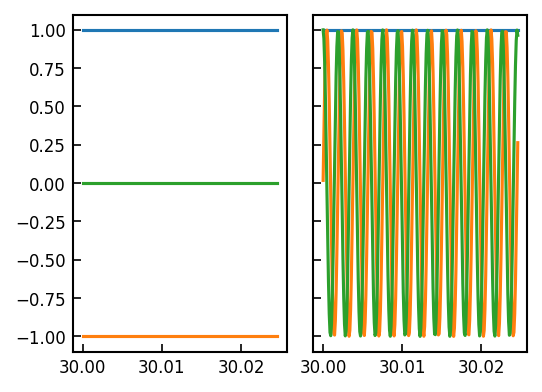

In [7]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, constrained_layout=True)
axs[0].plot(fzoom_dense, sky.I_map[:, 0])
axs[0].plot(fzoom_dense, sky.Q_map[:, 0])
axs[0].plot(fzoom_dense, sky.U_map[:, 0])
sky.apply_fd()
axs[1].plot(fzoom_dense, sky.I_map[:, 0])
axs[1].plot(fzoom_dense, sky.Q_map[:, 0])
axs[1].plot(fzoom_dense, sky.U_map[:, 0])
plt.show()

In [8]:
cfg = ld.SimConfig(freqs=fzoom, times=np.array([0]), sky=sky, beam=dipole, nside=NSIDE, faraday=True)
sim = ld.Simulator(cfg)
# point source so set mask
sim.grid.mask[1:] = False  # everything is effectively below horizon except zenith
vis = sim.simulate(in_topo=True)  # shape is ntimes, 3, nfreqs

Faraday rotation already applied.


In [9]:
pI, pQ, pU = sim.compute_stokes(vis)

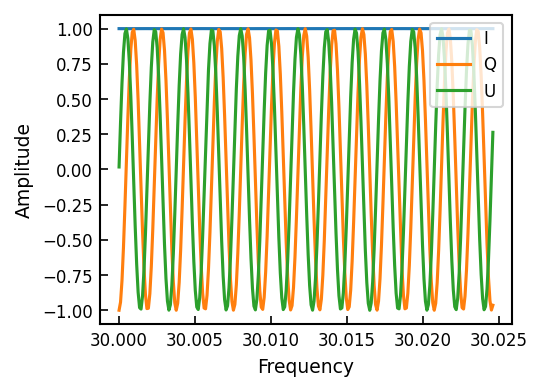

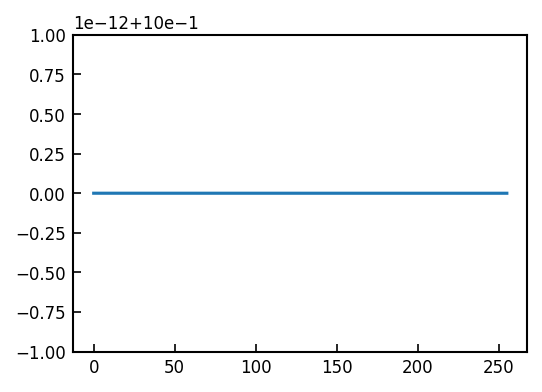

In [10]:
plt.figure()
plt.plot(fzoom_dense, pI[0], label="I")
plt.plot(fzoom_dense, pQ[0], label="Q")
plt.plot(fzoom_dense, pU[0], label="U")
plt.legend(loc="upper right")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(((pQ**2 + pU**2)/pI**2)[0], label="Pol fraction")
plt.show()

## Move source to alt=60, az=20

In [11]:
I, Q, U = ld.sky.point_src(lat_center=60, lon_center=20, nside=NSIDE, nfreqs=nfreqs)
pix = np.nonzero(I[0])[0]
print(pix)
RM = np.zeros_like(I[0])
RM[pix] = 100
sky = ld.SkyModel(I, Q, U, RM, freq=fzoom_dense, frame="topocentric")

cfg = ld.SimConfig(freqs=fzoom, times=np.array([0]), sky=sky, beam=dipole, nside=NSIDE, faraday=True)
sim = ld.Simulator(cfg)
# point source so set mask
sim.grid.mask.fill(False)
sim.grid.mask[pix] = True
vis = sim.simulate(in_topo=True)  # shape is ntimes, 3, nfreqs

[2880 3008 3135 3136 3137 3263]


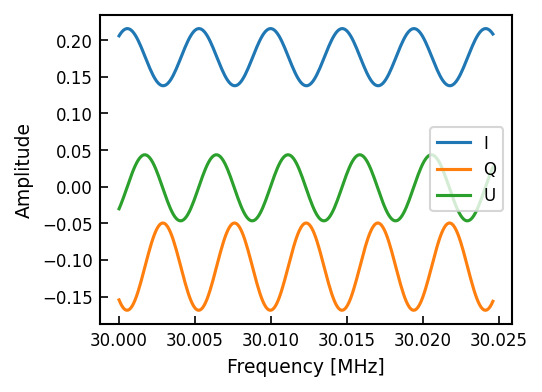

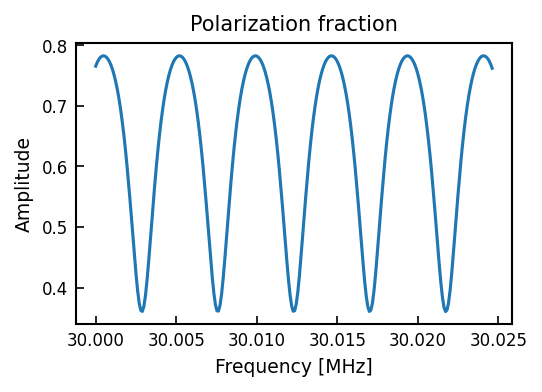

In [12]:
pI_off, pQ_off, pU_off = sim.compute_stokes(vis)
plt.figure()
plt.plot(fzoom_dense, pI_off[0], label="I")
plt.plot(fzoom_dense, pQ_off[0], label="Q")
plt.plot(fzoom_dense, pU_off[0], label="U")
plt.legend()
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(fzoom_dense, np.sqrt((pQ_off**2 + pU_off**2)/pI_off**2)[0])
plt.title("Polarization fraction")
plt.xlabel("Frequency [MHz]")
plt.ylabel("Amplitude")
plt.show()

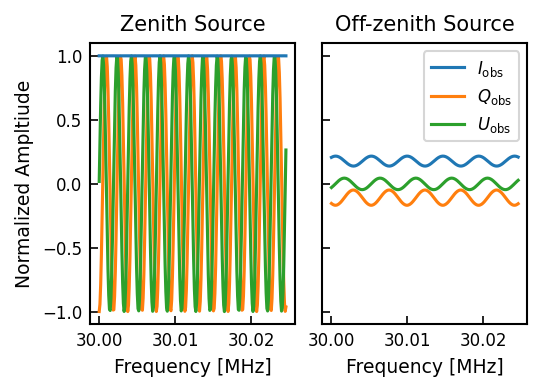

In [13]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)
# zenith source
axs[0].plot(fzoom_dense, pI[0], zorder=10)
axs[0].plot(fzoom_dense, pQ[0])
axs[0].plot(fzoom_dense, pU[0])
axs[0].set_title("Zenith Source")
# off-zenith
axs[1].plot(fzoom_dense, pI_off[0], label="$I_{\\rm obs}$")
axs[1].plot(fzoom_dense, pQ_off[0], label="$Q_{\\rm obs}$")
axs[1].plot(fzoom_dense, pU_off[0], label="$U_{\\rm obs}$")
axs[1].set_title("Off-zenith Source")

axs[1].legend()
axs[0].set_ylabel("Normalized Ampltiude")
plt.setp(axs, xlabel="Frequency [MHz]")
plt.savefig("point_source.pdf", bbox_inches="tight")
plt.show()